

# Inhomogeneous Dielectric Medium

By modifying the system of equations from the derivation of the [Yee algorithm for a 1D medium](050_fdtd_yee.ipynb), we obtain:

$$
\begin{align*}
\mu_r \mu_0 \frac{\partial H_y}{\partial t}  &= \frac{\partial E_z}{\partial x} \\
\epsilon_r \epsilon_0 \frac{\partial E_z}{\partial t}  &= \frac{\partial H_y}{\partial x}
\end{align*}
$$

From which we get the update equations in the form:

$$
H_y^{q+1/2}[m+1/2] = H_y^{q-1/2}[m+1/2] + \big( E_z^{q}[m+1] - E_z^{q}[m] \big) \frac{S_c}{\mu_r} 
$$

$$
E_z^{q+1}[m] = E_z^{q}[m] + \big({H_y^{q + 1/2}[m + 1/2] - H_y^{q+1/2}[m-1/2] } \big) \frac{S_c}{\epsilon_r} 
$$

Extending the simulation to include inhomogeneities is simple and consists of adding an array of $\epsilon_r$ values (for dielectric inhomogeneities). In the update equations, we assign the corresponding $\epsilon_r$ value to the appropriate node.

```python
ez[m] = ez[m] + (hy[m] - hy[m - 1]) * z0 * Sc / epsr[m]



In [2]:
import matplotlib.pyplot as plt

def tm_plot(times, r):
    """
    Plot Ez field snapshots at selected time steps.

    Parameters
    ----------
    times : list of int
        Time steps to plot.
    r : ndarray
        2D array of shape (time, nodes) containing Ez values.
    """
    plt.figure(figsize=(10, 6))

    for i, t in enumerate(times):
        plt.subplot(len(times), 1, i + 1)
        plt.plot(r[t, :], "r-")
        plt.ylim(-1.1, 1.1)
        plt.xlim(0, r.shape[1])
        plt.legend([f"t={t}"])
        plt.grid(True)

    plt.tight_layout()
    plt.show()


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def wv_plot(time, nodes, r):
    """
    Plot a wave propagation diagram over time and space.
    
    Parameters:
    - time: number of time steps
    - nodes: number of spatial nodes
    - r: 2D array (time x nodes) containing Ez values
    """
    plt.figure(figsize=(10, 6))
    
    # Normalize for better visualization
    r_norm = r / np.max(np.abs(r))
    
    # Plot each time step offset for a "stacked" wave effect
    for t in range(0, time, int(time/20)):
        plt.plot(r_norm[t, :] + t * 0.05, label=f"t={t}")
    
    plt.xlabel("X")
    plt.ylabel("Amplitude + Time offset")
    plt.title("Wave propagation over time")
    plt.grid(True)
    plt.show()

# Example usage with your generated array `r`
nodes = 200
time = 200
# Assuming `r` is already filled with Ez values from your simulation
# wv_plot(time, nodes, r)


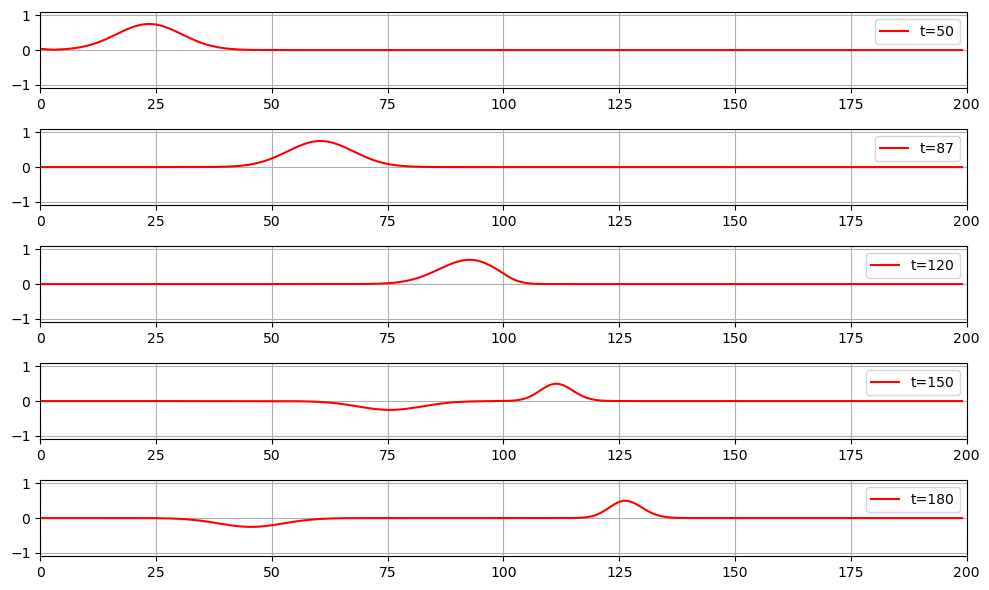

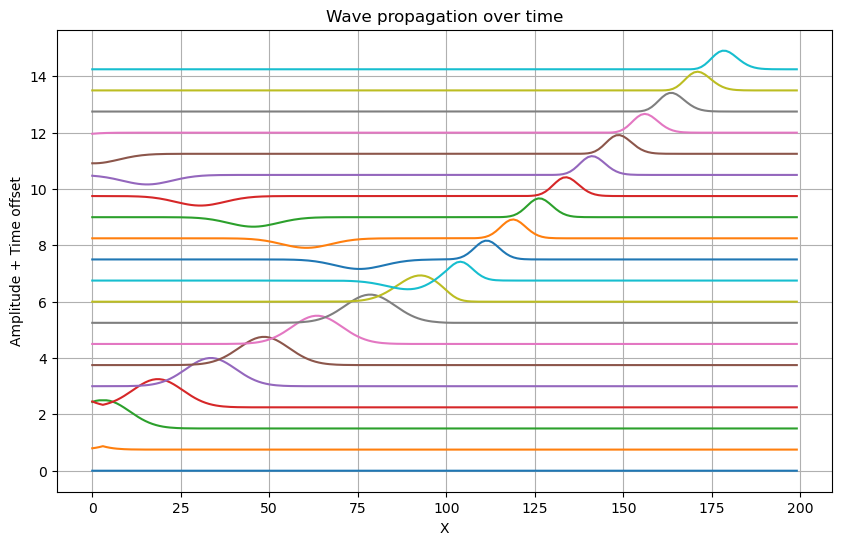

In [5]:

%matplotlib inline
from scipy import *
import matplotlib.pyplot as plt
import numpy as np

nodes = 200
time = 300
ez = np.zeros(nodes)
hy = np.zeros(nodes)
epsr = np.ones(nodes)

for i in range(100,nodes):
    epsr[i] = 4
    
z0 = 377.0
Sc = 1.0

r = np.zeros((time, nodes))                  # pole vysledkov

for t in range(time):
    ez[0] = ez[1]
    
    for m in range(1,nodes):              # aktualizacia Ez
        ez[m] = ez[m] + (hy[m] - hy[m - 1]) * z0 * Sc / epsr[m]   
        
    ez[3] += np.exp(-(t - 30.)**2 / 100.)*1.5
    
    for m in range(nodes-1):              # aktualizacia Hy
        hy[m] = hy[m] + (ez[m + 1] - ez[m]) / z0 * Sc
        
    r[t,:] += ez


tm_plot([50, 87, 120, 150, 180], r)
wv_plot(time, nodes, r)    

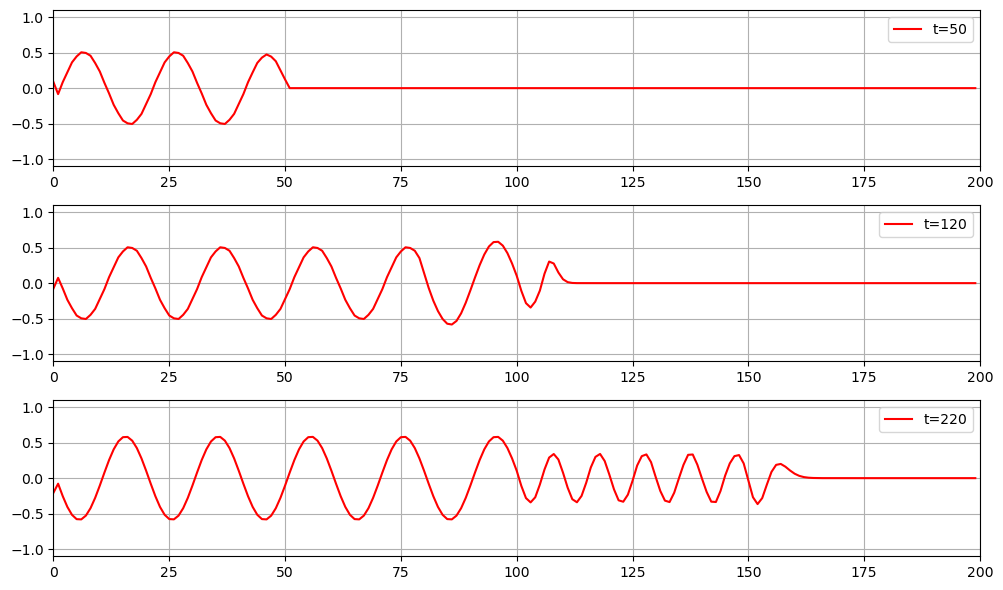

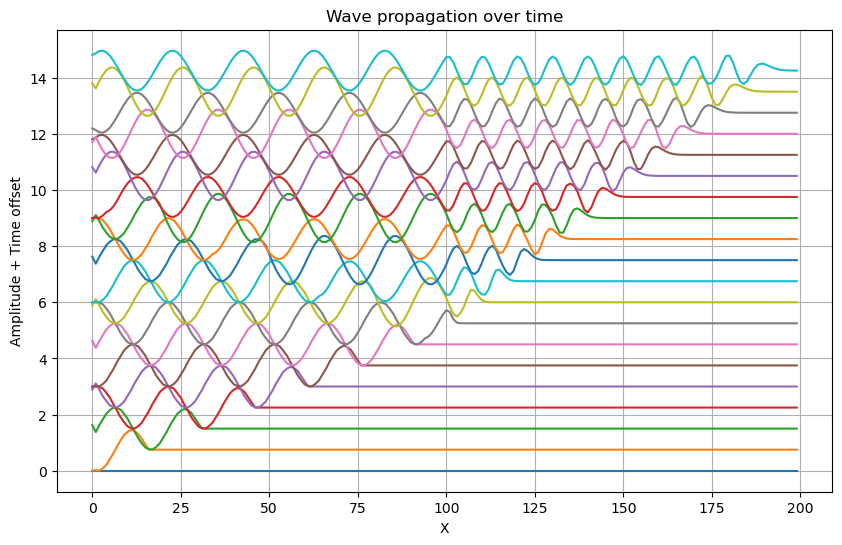

In [9]:

%matplotlib inline
from scipy import *
import matplotlib.pyplot as plt

nodes = 200
time = 300
ez = np.zeros(nodes)
hy = np.zeros(nodes)
epsr = np.ones(nodes)

for i in range(100,nodes):
    epsr[i] = 4
    
z0 = 377.0
Sc = 1.0

r = np.zeros((time, nodes))                  # pole vysledkov

for t in range(time):
    ez[0] = ez[1]
    
    for m in range(1,nodes):              # aktualizacia Ez
        ez[m] = ez[m] + (hy[m] - hy[m - 1]) * z0 * Sc / epsr[m]   
        
    #ez[3] += exp(-(t - 30.)**2 / 100.)*1.5
    ez[1] += np.sin(2*np.pi*0.05*t)*(1-np.exp(-t*0.5)) 
    
    for m in range(nodes-1):              # aktualizacia Hy
        hy[m] = hy[m] + (ez[m + 1] - ez[m]) / z0 * Sc
        
    r[t,:] += ez


tm_plot([50, 120, 220], r)
wv_plot(time, nodes, r)    

## Nejednoznačnosť hranice medzí médiami




## Reflection and Transmission Coefficient

The reflection coefficient $\Gamma$ and transmission coefficient $T$ for an electromagnetic wave passing from a medium with characteristic impedance $z_1$ to a medium with impedance $z_2$ are defined as:

$$
\Gamma = \frac{z_2 - z_1}{z_2 + z_1}
$$

$$
T = \frac{2 \, z_2}{z_2 + z_1}
$$

In our specific case, we consider a wave moving from a medium with impedance $z_1 = z_0$ (impedance of free space) to a medium with impedance $z_2 = z_0 / 2$.

The reflection coefficient is calculated as:

$$
\Gamma = \frac{\frac{z_0}{2} - z_0}{\frac{z_0}{2} + z_0} = \frac{-\frac{z_0}{2}}{\frac{3z_0}{2}} = -\frac{1}{3}
$$

The transmission coefficient is calculated as:

$$
T = \frac{2 \cdot \frac{z_0}{2}}{\frac{z_0}{2} + z_0} = \frac{z_0}{\frac{3z_0}{2}} = \frac{2}{3}
$$

This means that one-third of the wave's amplitude is reflected back (with a phase flip), and two-thirds of its amplitude is transmitted into the new medium.